In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,StandardScaler
import warnings
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering



warnings.filterwarnings("ignore")
sca = MinMaxScaler()
snd = StandardScaler()
ln = LabelEncoder()
#plt.style.use("seaborn-darkgrid")

In [2]:
data = pd.read_csv("crime_data.csv")

In [3]:
data.columns

Index(['Unnamed: 0', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

In [4]:
data.rename(columns={"Unnamed: 0": "macha"},inplace=True)

In [5]:
data.shape

(50, 5)

In [6]:
data.columns = ['city', 'Murder', 'Assault', 'UrbanPop', 'Rape']

In [7]:
data.shape

(50, 5)

In [8]:
data.isna().sum()

city        0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [9]:
data.dtypes

city         object
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object

In [10]:
data.head()

,city,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [11]:
ddata = data.copy()

In [12]:
x = ddata.drop(labels="city",axis=1)

In [13]:
x.head(2)

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5


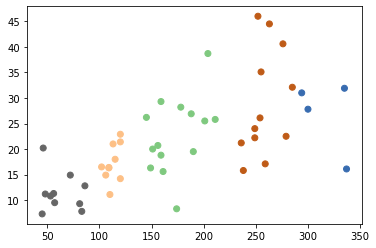

In [14]:
model = KMeans(n_clusters=5)
model.fit(x)
pred = model.predict(x)
plt.scatter(x.Assault,x.Rape,c=pred,cmap=plt.cm.Accent)

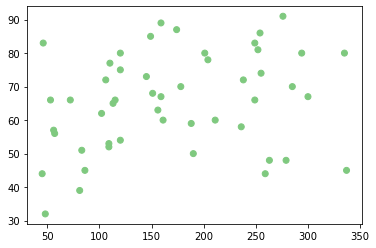

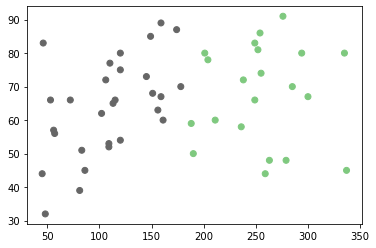

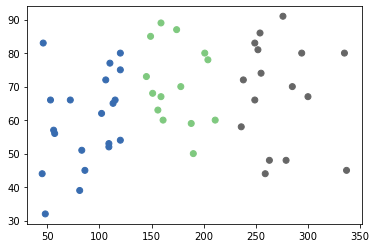

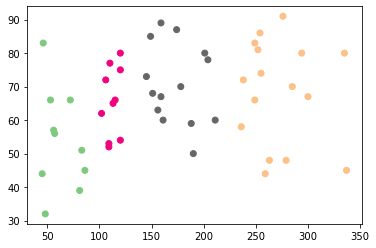

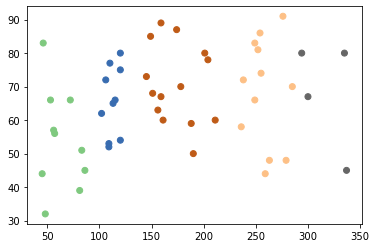

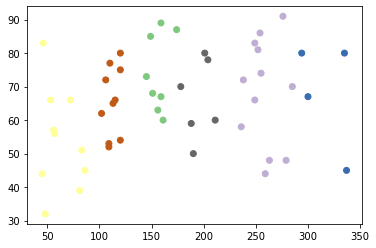

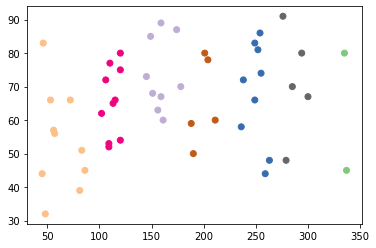

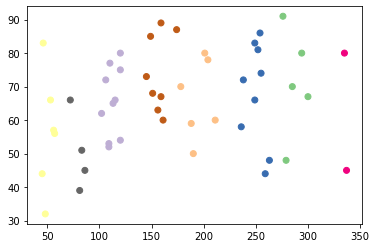

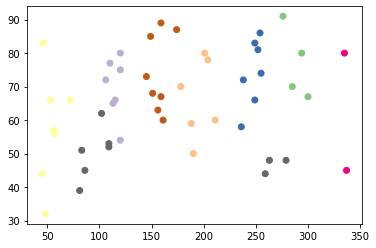

In [15]:
for i in range(1,10):
    model = KMeans(n_clusters=i)
    model.fit(x)
    pred = model.predict(x)
    plt.scatter(x.Assault,x.UrbanPop,c=pred,cmap=plt.cm.Accent)
    plt.show()

### DB Scan

In [ ]:
model = DBSCAN(min_samples=4,eps=21)
pred = model.fit_predict(x)
plt.scatter(x.Assault,x.UrbanPop,c=pred)
pred

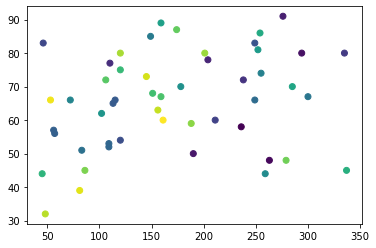

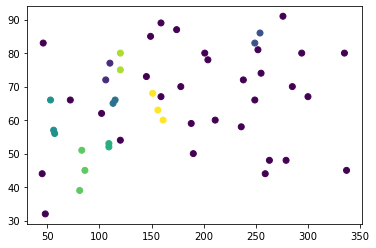

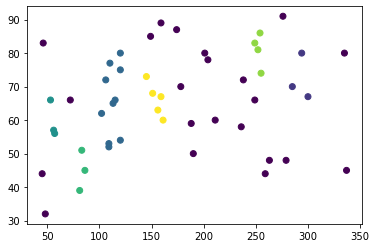

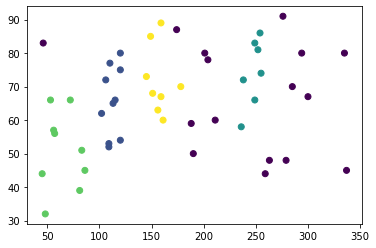

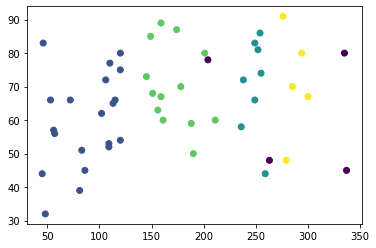

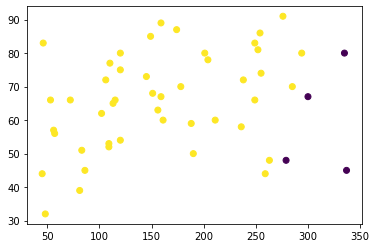

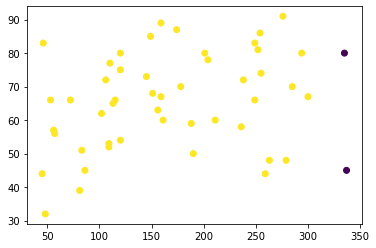

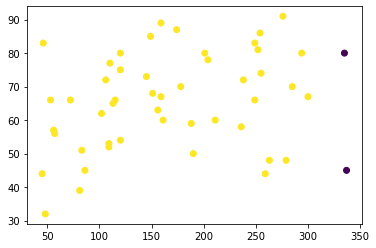

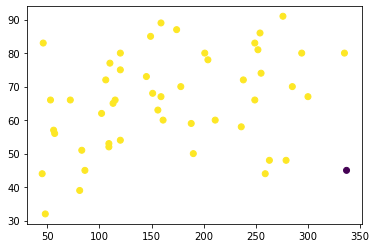

In [37]:
for i in range (1,10):    
    model = DBSCAN(min_samples=i,eps=i*0.24*21)
    pred = model.fit_predict(x)
    plt.scatter(x.Assault,x.UrbanPop,c=pred)
    plt.show()

### Hierarchical Clustering

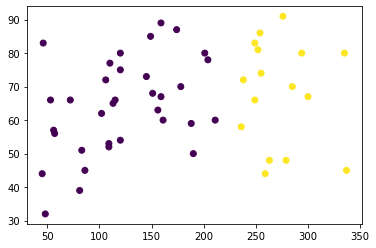

In [31]:
hc = AgglomerativeClustering(n_clusters=2)
pred  = hc.fit_predict(x)
plt.scatter(x.Assault,x.UrbanPop,c=pred)

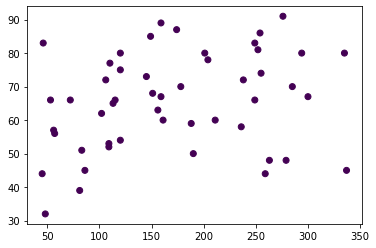

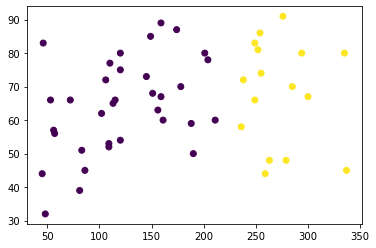

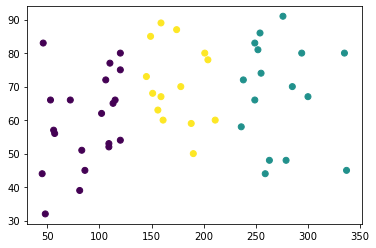

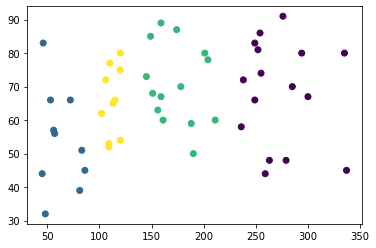

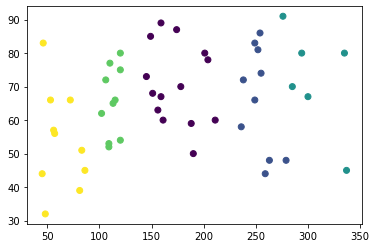

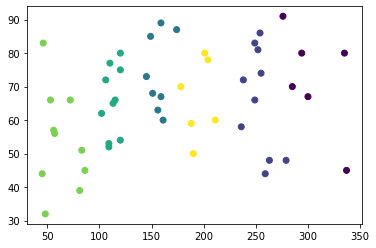

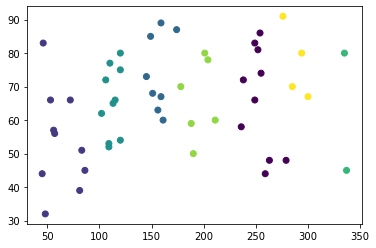

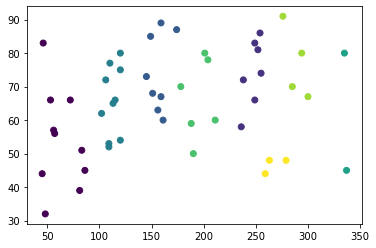

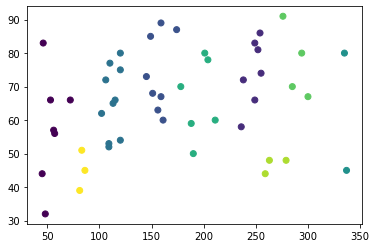

In [38]:
for i in range (1,10):    
    hc = AgglomerativeClustering(n_clusters=i)
    pred  = hc.fit_predict(x)
    plt.scatter(x.Assault,x.UrbanPop,c=pred)
    plt.show()